In [1]:
# Package activation and imports
# Activate the Julia project environment
using Pkg
Pkg.activate("..")

# Import required packages for optimal control analysis
using Plots                                 # For plotting and visualization
using OptimalControl                        # Main package for optimal control problems
using NLPModelsIpopt                        # Interface for Ipopt nonlinear solver
using OrdinaryDiffEq                        # For solving differential equations
using MINPACK                               # For nonlinear equation solving (shooting method)
using DifferentiationInterface              # For automatic differentiation
using ForwardDiff                           # Forward mode automatic differentiation
using Ipopt, Optimization, OptimizationMOI  # Additional optimization tools

  Activating project at `c:\Users\Remy_Dutto\Documents\GitHub\TurnpikeExample.jl\docs`


In [2]:
T = 50.
M = 1.                   
s0 = [0., 1, -0.5]            
xT = 0.5; yT = 0.5

F0(s) = [
    0.5*(s[2]^2 + s[3]^2);
    0;
    -s[3]/2
]

F1(s) = [
    0;
    1;
    -1
]

# Define the optimal control problem using OptimalControl.jl DSL
ocp = @def begin
    t ∈ [0, T], time                                # Time
    s = (c, x, y) ∈ R³, state                       # State
    u ∈ R, control                                  # Control
    -M ≤ u(t) ≤ M                                   # Control's constraint
    s(0) == s0                                      # Initial state
    x(T) == xT                                      # Final state
    y(T) == yT                                      # Final state
    ṡ(t) == F0(s(t)) + u(t)*F1(s(t))                # Dynamics
    c(T) → min                                      # Cost
end

Abstract definition:

    t ∈ [0, T], time
    s = ((c, x, y) ∈ R³, state)
    u ∈ R, control
    -M ≤ u(t) ≤ M
    s(0) == s0
    x(T) == xT
    y(T) == yT
    ṡ(t) == F0(s(t)) + u(t) * F1(s(t))
    c(T) → min

The (autonomous) optimal control problem is of the form:

    minimize  J(s, u) = g(s(0), s(50.0))

    subject to

        ṡ(t) = f(s(t), u(t)), t in [0, 50.0] a.e.,

        ϕ₋ ≤ ϕ(s(0), s(50.0)) ≤ ϕ₊, 
        u₋ ≤ u(t) ≤ u₊, 

    where s(t) = (c(t), x(t), y(t)) ∈ R³ and u(t) ∈ R.


▫ This is OptimalControl 2.0.4, solving with: collocation → adnlp → ipopt (cpu)

  📦 Configuration:
   ├─ Discretizer: collocation
   ├─ Modeler: adnlp
   └─ Solver: ipopt

▫ This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:     3255
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     1002

Total number of variables............................:     1003
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      250
                     variables with only upper bounds:        0
Total number of equality constraints.................:      755
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper b

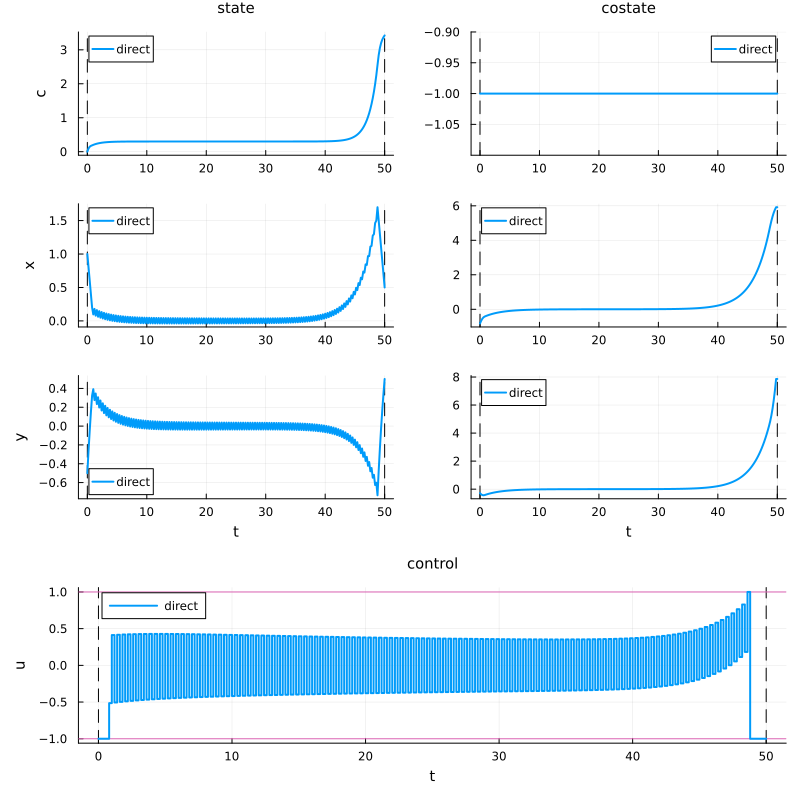

In [3]:
# Solve the optimal control problem using direct method (collocation)
direct_sol = solve(ocp)
# Plot the solution trajectory showing states, controls, and costates over time
plt_sol = plot(direct_sol, label = "direct", size = (800, 800))

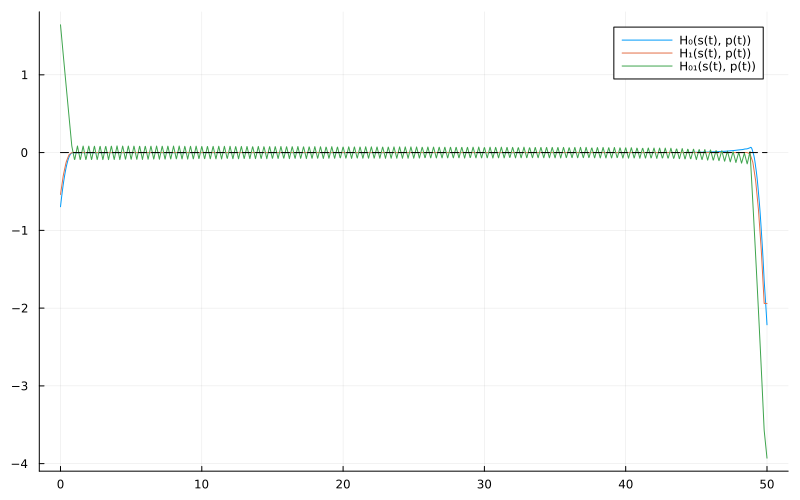

In [4]:
# Lift into (x,λ) space
H0 = Lift(F0)
H1 = Lift(F1)

# Lie bracket
H01  = @Lie {H0, H1}
H001 = @Lie {H0, H01}
H101 = @Lie {H1, H01}

# Singular control
us(s, p) = -H001(s, p) / H101(s, p)

# Pseudo-Hamiltonian
H(s,p,u) = H0(s,p) + u*H1(s,p)

# Flows
ϕ0 = Flow(ocp, (s,p) -> -1)
ϕ1 = Flow(ocp, (s,p) -> +1)
ϕs = Flow(ocp, (s,p) -> us(s,p))

# Get direct trajectory
time = time_grid(direct_sol)
s = state(direct_sol)
u = control(direct_sol)
p = costate(direct_sol)

# Structure of the solution *
plt = plot(size = (800, 500))
plot!(plt, t -> H0(s(t), p(t)), 0, T, label = "H₀(s(t), p(t))")
plot!(plt, t -> H1(s(t), p(t)), 0, T, label = "H₁(s(t), p(t))")
plot!(plt, t -> H01(s(t), p(t)), 0, T, label = "H₀₁(s(t), p(t))")
plot!(plt, [0, T], [0, 0], c = :black, ls = :dash, label = nothing)

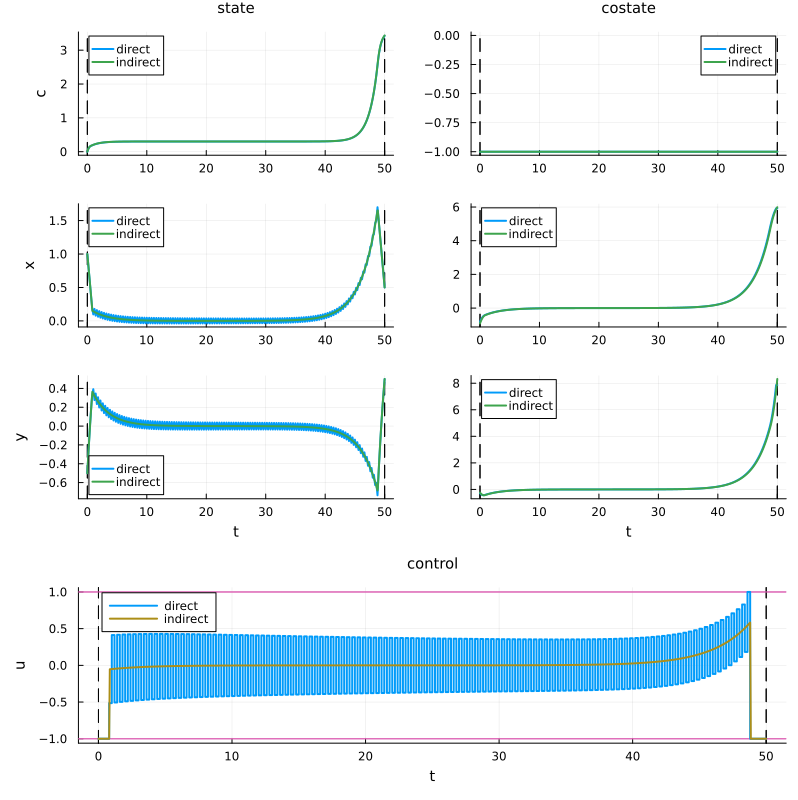

In [5]:
# Shooting function
function shoot!(S, ξ)
    px, py, t1, t2 = ξ
    s1, p1 = ϕ0(0, s0, [-1, px, py], t1)
    s2, p2 = ϕs(t1, s1, p1, t2)
    sf, pf = ϕ0(t2, s2, p2, T)

    S[1] = sf[2] - xT
    S[2] = sf[3] - yT
    S[3] = H1(s1, p1)
    S[4] = H01(s1, p1)
end

# Jacobian of the shooting function
jshoot! = (js, ξ) -> jacobian!(shoot!, similar(ξ), js, AutoForwardDiff(), ξ)

# Initial guess
p0 = p(0)
η = 1e-3
time_ = time[ u.(time) .≥ -1+η ]
t1 = time_[1]; t2 = time_[end]
ξ = [p0[2:3]..., t1, t2]

# Resolution of S(ξ) = 0
indirect_sol = fsolve(shoot!, jshoot!, ξ)

# Plot
px0, py0, t1, t2 = indirect_sol.x
p0 = [-1, px0, py0]
ϕ = ϕ0 * (t1, ϕs) * (t2, ϕ0)
flow_sol = ϕ((0, T), s0, p0; saveat=range(0, T, 1000))
plot!(plt_sol, flow_sol, label="indirect")